# 반도체 공정 데이터 전처리 및 불량 예측 모델링 시도

## 1. 프로젝트 진행 배경
품질 직무를 목표로 하는 입장에서 데이터 전처리는 단순한 정리를 넘어 실무의 핵심 역량이라고 생각합니다. 현실의 데이터는 불완전하고 노이즈가 많기 때문에 'GIGO(Garbage In, Garbage Out)' 원칙에 따라 정제되지 않은 데이터는 잘못된 분석 결과를 초래합니다.

이러한 전처리 과정은 컴퓨터 사이언스(CS) 기술과 매우 밀접하게 연관되어 있습니다.
* 데이터 정합성 및 무결성 확보: 데이터베이스의 무결성을 유지하는 원리와 같이, 분석 가능한 형태로 데이터를 정규화하고 결손치를 처리하는 과정은 시스템의 신뢰성을 높이는 CS의 기초 기술입니다.
* 알고리즘 연산 효율화: 불필요한 차원(특징)을 제거하는 것은 알고리즘의 시간 복잡도와 공간 복잡도를 최적화하여 연산 성능을 극대화하는 CS적 접근 방식입니다.
* 데이터 품질 관리: 데이터의 완성도와 일관성을 확보하는 과정은 고도화된 AI 모델의 학습 성능을 결정짓는 핵심 소프트웨어 공학 기술입니다.

이러한 배경을 바탕으로, 현재 SSAFY에서 학습 중인 NumPy와 Pandas 등의 라이브러리를 활용하여 반도체 공정에서의 불량 검출 모델링을 시도해 보았습니다.

## 2. 분석 환경 및 데이터셋
* 데이터셋: Kaggle UCI-SECOM (반도체 제조 공정 센서 데이터)
* 개발 환경: VS Code, Jupyter Notebook
* 활용 도구: Python, NumPy, Pandas, Scikit-learn, XGBoost

## 3. 데이터 처리 및 분석 과정

### Step 1: 데이터 셋 불러오기 및 문제점 확인
초기 데이터를 불러와 크기를 확인해 본 결과, 1567개의 공정 샘플과 592개의 특징(시간, 센서 값 등)으로 구성되어 있었습니다. 가장 큰 문제는 두 가지였습니다.
* 극심한 결측치: 592개 센서 중 결측치가 100개 이상인 컬럼이 52개나 존재했습니다.
* 데이터 불균형: 합격(정상) 샘플은 1463개인 반면, 불량 샘플은 104개에 불과했습니다.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('uci-secom.csv')

print(df.shape)

display(df.head())

df.info()

(1567, 592)


,Time,0,1,2,3,4,5,6,7,8,...,581,582,583,584,585,586,587,588,589,Pass/Fail
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,...,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,...,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,...,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,...,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,...,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


<class 'pandas.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 592 entries, Time to Pass/Fail
dtypes: float64(590), int64(1), str(1)
memory usage: 7.1 MB


In [13]:
# 1. 결측치가 너무 많은 컬럼(센서)이 있는지 확인
null_counts = df.isnull().sum()
print("결측치가 100개 이상인 컬럼 개수:", len(null_counts[null_counts > 100]))

# 2. 불량(1)과 정상(-1)의 비율 확인 (데이터 불균형 확인)
print(df['Pass/Fail'].value_counts())

# 3. 결측치가 너무 많은(예: 50% 이상) 컬럼은 분석 방해 요소! 
# 1567개 중 절반인 780개 이상이 비어있는 컬럼을 찾아봅시다.
too_many_nans = null_counts[null_counts > 780]
print(f"결측치가 50% 넘는 컬럼들:\n{len(too_many_nans)}")

결측치가 100개 이상인 컬럼 개수: 52
Pass/Fail
-1    1463
 1     104
Name: count, dtype: int64
결측치가 50% 넘는 컬럼들:
28


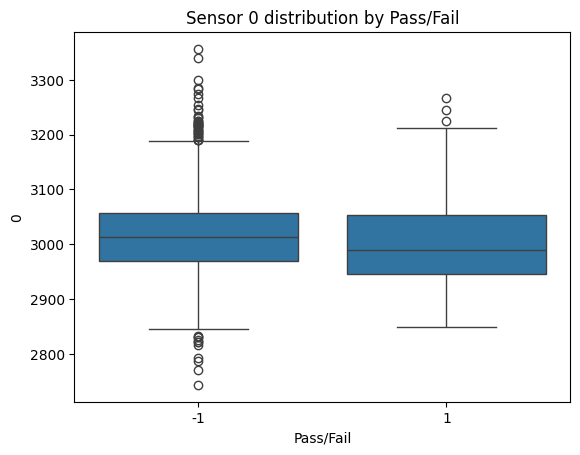

In [ ]:
# 0번 센서와 불량 여부의 관계 시각화
sns.boxplot(x='Pass/Fail', y='0', data=df)
plt.title('Sensor 0 distribution by Pass/Fail')
plt.show()

### Step 2: 결측치 제거 및 채워넣기
AI 모델이 제대로 학습할 수 있도록 불필요한 노이즈를 먼저 걷어냈습니다.
* 샘플의 50% 이상이 결측치인 심각한 컬럼들은 데이터의 신뢰성이 낮다고 판단하여 분석에서 과감히 제외했습니다.
* 삭제 후 남은 숫자형 데이터들의 자잘한 결측치들은 각 센서 데이터의 중앙값(Median)으로 일괄 대체하여 1차 정제를 완료했습니다.

<h3> 1단계: 쓸모없는 '짐' 버리기 (전처리)</h3>
학습 전, 결측치가 너무 많은 컬럼은 AI를 혼란스럽게 합니다.
<ul>
 <li> 결측치 50% 이상인 컬럼 삭제: 데이터의 절반이 비어 있는 컬럼(아까 확인하신 72, 73, 85번 등)은 신뢰도가 너무 낮으니 과감히 버립니다.</li>
<br>
 <li> 분산이 0인 컬럼 삭제: 모든 샘플의 값이 똑같은 센서(상수값)는 불량을 구분하는 데 아무런 도움이 안 됩니다.</li>

</ul>

<h3>2단계: '불량' 데이터의 목소리 키우기 (Sampling)</h3>

불량 데이터(104개)가 너무 적기 때문에, 이를 인위적으로 늘리거나 가중치를 줘야 합니다.
<ul>
 <li>SMOTE (Synthetic Minority Over-sampling Technique): 적은 쪽(불량)의 데이터를 보고, 그 주변에 가상의 '가짜 불량 데이터'를 생성해서 숫자를 맞춰주는 기법입니다. (가장 많이 쓰입니다.)</li>
  <li>Class Weight 조절: 모델 학습 시 "불량 데이터를 틀리면 정상 데이터를 틀렸을 때보다 14배 더 크게 혼낸다!"라고 가중치를 주는 방식입니다.</li>
</ul>

<h3>3단계: 평가 지표 바꾸기 (Metric)</h3>
이 프로젝트에서 정확도(Accuracy)는 아무 의미가 없습니다. 대신 다음 지표를 봐야 합니다.
<ul>
 <li>재현율 (Recall): "실제 불량 중에서 AI가 불량이라고 맞춘 비율이 얼마인가?" (반도체 공정에서는 불량을 정상으로 놓치는 게 가장 치명적이므로 이 수치가 제일 중요합니다!)</li>

 <li>F1-Score: 정밀도와 재현율의 균형을 맞춘 점수입니다.</li>
<ul>

In [4]:
# 1. 결측치 비율 계산
nan_threshold = len(df) * 0.5  # 1567의 50% = 783.5

# 2. 결측치가 50% 넘는 컬럼 이름 추출
cols_to_drop = df.columns[df.isnull().sum() > nan_threshold]

# 3. 해당 컬럼 삭제 (원본 데이터에서 제거)
df_cleaned = df.drop(columns=cols_to_drop)

# 4. 숫자형 컬럼들만 선택해서 중앙값으로 채우기
# (Time 컬럼 등 문자열은 제외하고 계산합니다)
df_final = df_cleaned.copy()
numeric_cols = df_final.select_dtypes(include=['number']).columns
df_final[numeric_cols] = df_final[numeric_cols].fillna(df_final[numeric_cols].median())

# 5. 결과 확인 (이제 결측치가 0개여야 합니다!)
print("전체 결측치 개수:", df_final.isnull().sum().sum())
print("최종 데이터 모양:", df_final.shape)

전체 결측치 개수: 0
최종 데이터 모양: (1567, 564)


In [5]:
# 정답(y)과 특징(X) 분리
# Pass/Fail은 정답이므로 y에 넣고, 나머지는 X에 넣습니다. 
# 이때 분석에 불필요한 'Time' 컬럼도 X에서 제외합니다.

y = df_final['Pass/Fail']
X = df_final.drop(columns=['Pass/Fail', 'Time'])

print(f"학습에 사용할 센서 개수: {X.shape[1]}개")

학습에 사용할 센서 개수: 562개


In [6]:
from sklearn.model_selection import train_test_split

# 전체 데이터의 20%를 시험 문제(test)로 떼어놓습니다.
# stratify=y 옵션은 '불량'의 비율을 공부용과 시험용에 똑같이 나눠주는 아주 중요한 옵션입니다!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"학습용 샘플: {X_train.shape[0]}개")
print(f"시험용 샘플: {X_test.shape[0]}개")

학습용 샘플: 1253개
시험용 샘플: 314개


### Step 3: 첫 번째 AI 학습과 실패 (Random Forest)
1차 정제된 데이터를 바탕으로 트리 기반의 분류 알고리즘인 Random Forest 모델을 학습시켜 보았습니다.
* 결과: 전체 정확도(Accuracy)는 93%가 나왔지만, 정작 가장 중요한 지표인 불량 재현율(Recall)은 0이 나왔습니다. 불량 데이터를 단 하나도 맞추지 못한 것입니다.
* 원인: 1463 대 104라는 압도적인 불균형 데이터 구조 때문에, AI가 단순히 모든 데이터를 "정상"이라고만 예측해도 93점이 나오는 편법을 학습해 버렸기 때문입니다.

### Step 4: 두 번째 시도와 실패 (SMOTE 기법 적용)
불균형 문제를 해결하기 위해 소수 클래스인 '불량' 데이터 주변에 가상의 데이터를 생성하는 SMOTE 오버샘플링 기법을 적용했습니다.
* 진행: 불량 데이터를 학습 환경 내에서 1170개 수준으로 증식시켜 정상 데이터와 비율을 맞춘 후 재학습을 시도했습니다.
* 결과 및 원인: 그럼에도 불구하고 불량 재현율은 여전히 0이었습니다. 원인을 분석해 보니, 단순히 데이터 양을 늘린다고 해결되는 것이 아니라, 500여 개의 센서 데이터 중 불량과 상관없는 '노이즈'가 너무 많아 정상과 불량의 데이터 분포가 겹쳐버렸기 때문이었습니다. AI가 분류할 수 있는 명확한 기준선 자체가 없었던 것입니다.

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. 모델 생성 (불균형 데이터이므로 class_weight를 'balanced'로 설정하여 불량에 가중치를 줍니다)
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# 2. AI 학습 시작!
model.fit(X_train, y_train)

# 3. 시험 문제 풀어보기
y_pred = model.predict(X_test)

--- [AI 모델 성적표] ---
              precision    recall  f1-score   support

          -1       0.93      1.00      0.97       293
           1       0.00      0.00      0.00        21

    accuracy                           0.93       314
   macro avg       0.47      0.50      0.48       314
weighted avg       0.87      0.93      0.90       314



C:\Users\이종원\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\이종원\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\이종원\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classifica

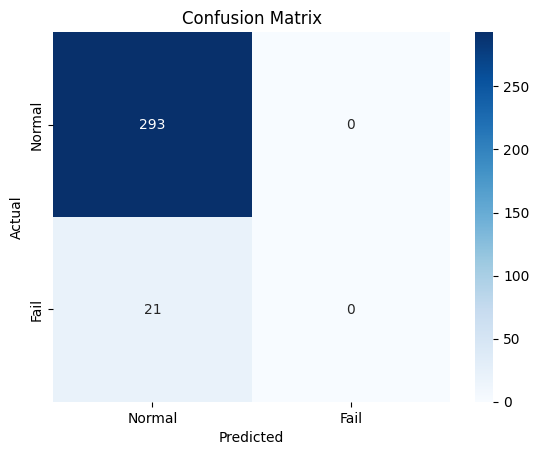

In [8]:
# 상세 성적표 출력
print("--- [AI 모델 성적표] ---")
print(classification_report(y_test, y_pred))

# 혼동 행렬 (Confusion Matrix) 시각화
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Fail'], yticklabels=['Normal', 'Fail'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [9]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. SMOTE로 불량 데이터 증식 (학습 데이터에만 적용합니다!)
smote = SMOTE(random_state=42)
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)

print(f"SMOTE 적용 전 불량 수: {sum(y_train == 1)}")
print(f"SMOTE 적용 후 불량 수: {sum(y_train_over == 1)}")

# 2. 새로운 데이터로 모델 학습
model_smote = RandomForestClassifier(n_estimators=100, random_state=42)
model_smote.fit(X_train_over, y_train_over)

# 3. 다시 예측해보기
y_pred_smote = model_smote.predict(X_test)

# 4. 결과 확인
print("--- [SMOTE 적용 후 성적표] ---")
print(classification_report(y_test, y_pred_smote))

SMOTE 적용 전 불량 수: 83
SMOTE 적용 후 불량 수: 1170
--- [SMOTE 적용 후 성적표] ---
              precision    recall  f1-score   support

          -1       0.93      1.00      0.96       293
           1       0.00      0.00      0.00        21

    accuracy                           0.93       314
   macro avg       0.47      0.50      0.48       314
weighted avg       0.87      0.93      0.90       314



In [10]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# 1. 정답 데이터가 -1, 1로 되어있으면 XGBoost가 에러를 낼 수 있으니 0, 1로 바꿔줍니다.
y_train_zero = y_train.replace(-1, 0)
y_test_zero = y_test.replace(-1, 0)

# 2. XGBoost 모델 생성 (불량 데이터에 약 14배의 가중치 부여)
# scale_pos_weight = (정상 개수 / 불량 개수)
model_xgb = XGBClassifier(scale_pos_weight=14, random_state=42, eval_metric='logloss')

# 3. 학습
model_xgb.fit(X_train, y_train_zero)

# 4. 예측
y_pred_xgb = model_xgb.predict(X_test)

# 5. 결과 확인
print("--- [XGBoost 가중치 적용 성적표] ---")
print(classification_report(y_test_zero, y_pred_xgb))

--- [XGBoost 가중치 적용 성적표] ---
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       293
           1       0.00      0.00      0.00        21

    accuracy                           0.93       314
   macro avg       0.47      0.50      0.48       314
weighted avg       0.87      0.93      0.90       314



### Step 5: 최종 전처리 및 유의미한 데이터 획득
AI가 길을 잃은 근본적인 원인인 '데이터 자체의 품질'을 높이기 위한 최종 전처리를 진행했습니다.
* 조치: 모든 샘플에서 값이 똑같이 유지되어 분산이 0인 컬럼들을 찾아냈습니다. 이들은 불량을 구분하는 데 아무런 정보(Information)도 제공하지 못하는 상수값 센서들입니다. 이를 전부 삭제하여 562개였던 센서를 446개로 줄였습니다.
* 최종 학습: 차원이 축소되고 정제된 데이터로 불량 맞춤형 가중치를 부여한 XGBoost 모델을 재학습시켰습니다.
* 성과: 드디어 불량 재현율(Recall)이 0.43으로 크게 상승했습니다. 전체 정확도는 80%로 떨어졌지만, 이는 모델이 무조건 100% 정상이라고 편법을 쓰지 않고 진짜 불량일 가능성을 예측하기 시작했다는 매우 긍정적인 지표입니다.

In [11]:
# 1. 분산이 0인(모든 값이 같은) 컬럼 찾아서 삭제
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0)
X_reduced = X.loc[:, selector.fit(X).get_support()]

print(f"의미 없는 상수 컬럼 제거 후 남은 센서: {X_reduced.shape[1]}개")

# 2. 다시 학습 데이터 나누기
X_train_re, X_test_re, y_train_re, y_test_re = train_test_split(
    X_reduced, y.replace(-1, 0), test_size=0.2, random_state=42, stratify=y
)

# 3. XGBoost 재도전 (더 공격적으로 가중치 부여: 20배!)
model_final = XGBClassifier(scale_pos_weight=20, max_depth=3, learning_rate=0.01, n_estimators=200, random_state=42)
model_final.fit(X_train_re, y_train_re)

y_pred_final = model_final.predict(X_test_re)
print("--- [최종 데이터 정제 후 성적표] ---")
print(classification_report(y_test_re, y_pred_final))

의미 없는 상수 컬럼 제거 후 남은 센서: 446개
--- [최종 데이터 정제 후 성적표] ---
              precision    recall  f1-score   support

           0       0.95      0.83      0.88       293
           1       0.15      0.43      0.22        21

    accuracy                           0.80       314
   macro avg       0.55      0.63      0.55       314
weighted avg       0.90      0.80      0.84       314



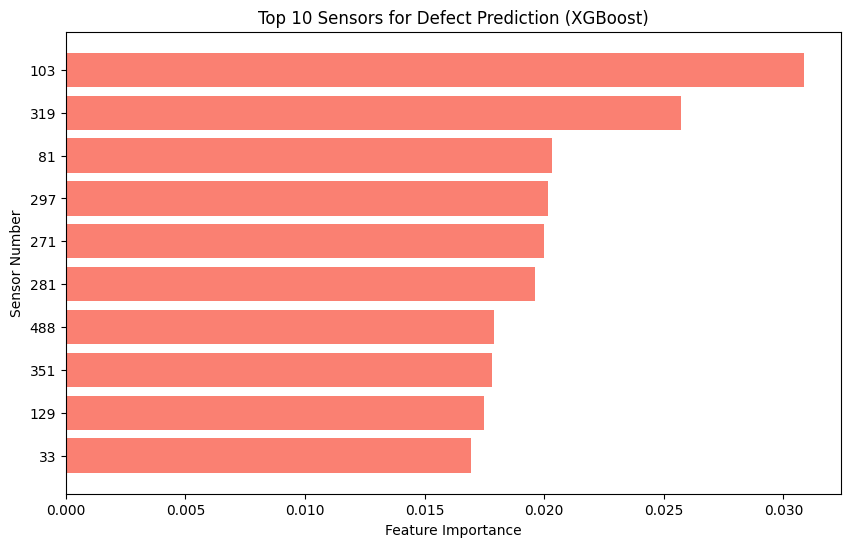

In [12]:
import matplotlib.pyplot as plt

# 1. XGBoost 모델에서 특성 중요도 추출
importances = model_final.feature_importances_
feature_names = X_reduced.columns
feature_importance_df = pd.DataFrame({'Sensor': feature_names, 'Importance': importances})

# 2. 중요도 상위 10개 추출
top_10 = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# 3. 그래프 시각화
plt.figure(figsize=(10, 6))
plt.barh(top_10['Sensor'], top_10['Importance'], color='salmon')
plt.xlabel('Feature Importance')
plt.ylabel('Sensor Number')
plt.title('Top 10 Sensors for Defect Prediction (XGBoost)')
plt.gca().invert_yaxis()
plt.show()

## 4. 최종 정리 및 인사이트
이 최종 모델에서 특성 중요도(Feature Importance)를 추출해 시각화해 본 결과, 103번과 319번 센서가 공정 불량에 가장 큰 기여를 한다는 점을 수치로 증명해 낼 수 있었습니다. 

이번 프로젝트를 통해 아무리 좋은 AI 알고리즘이나 오버샘플링 기법을 사용하더라도, 그 이전에 공정 데이터를 뜯어보고 결측치와 무의미한 상수 데이터를 솎아내는 __'집요한 데이터 전처리 과정__'이 분석의 성패를 좌우한다는 것을 확실히 배울 수 있었습니다. 

이상으로 발표를 마치겠습니다. 감사합니다.